In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score

In [5]:
# Configuración de estilo para gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Lectura y exploración de datos
df = pd.read_csv('C:/Users/Home/Documents/Semestre IX/Seminario/Cluster hierarchical/Mall_Customers.csv')
print("\nPrimeras filas del dataset:")
print(df.head())

print("\nResumen estadístico:")
print(df.describe())

print("\nInformación del dataset:")
print(df.info())

print("\nValores nulos por columna:")
print(df.isnull().sum())



Primeras filas del dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Resumen estadístico:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%  

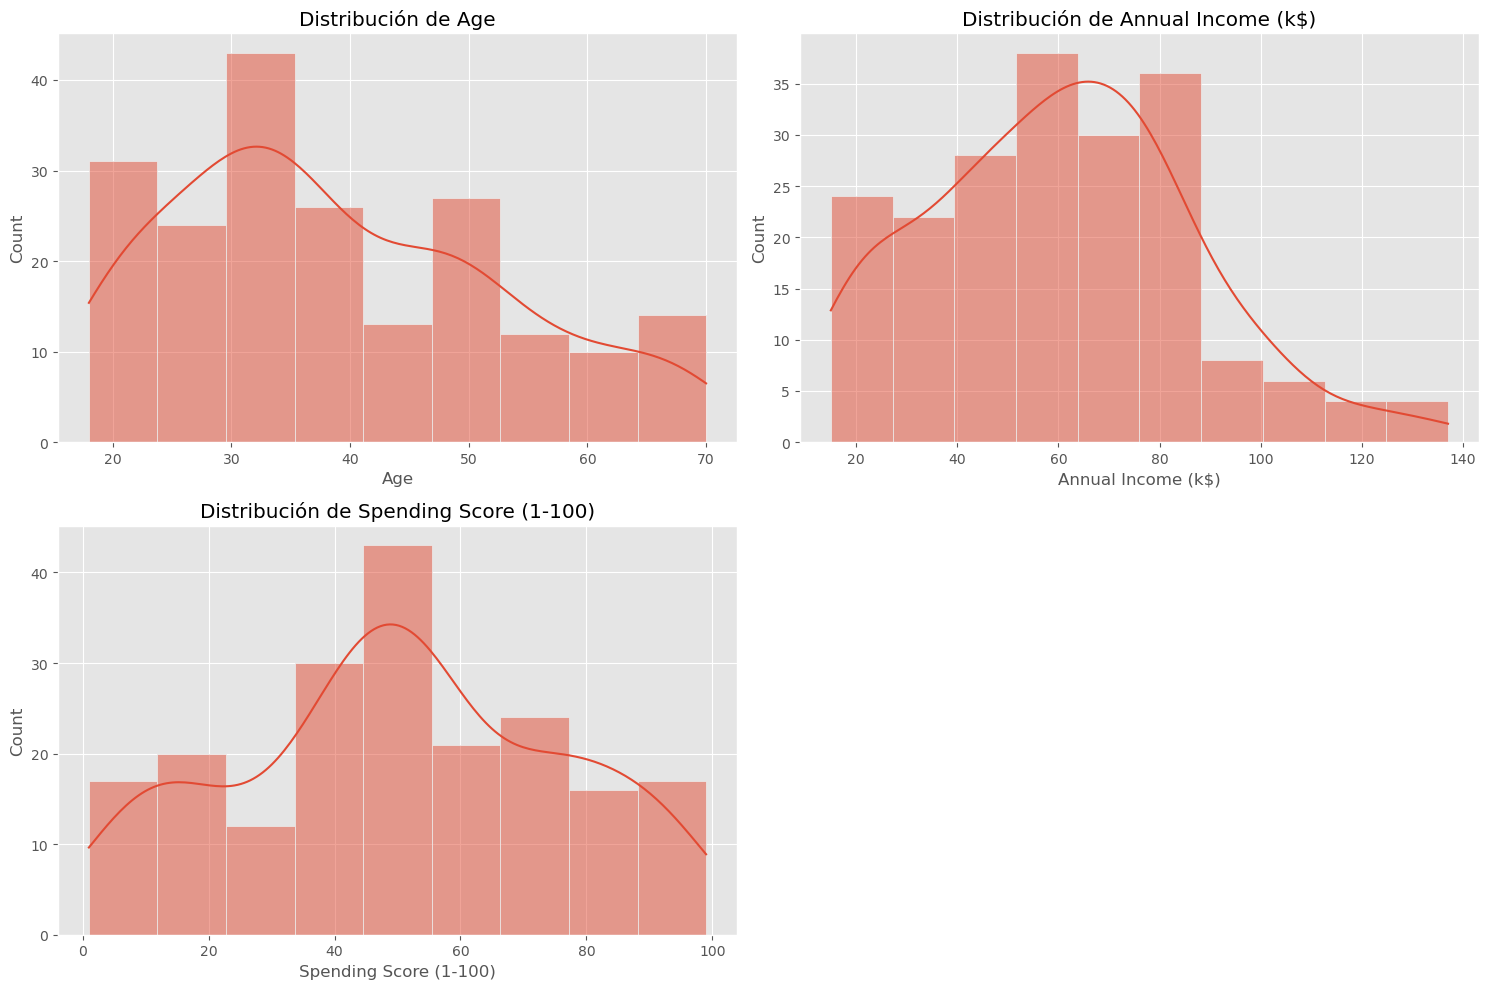

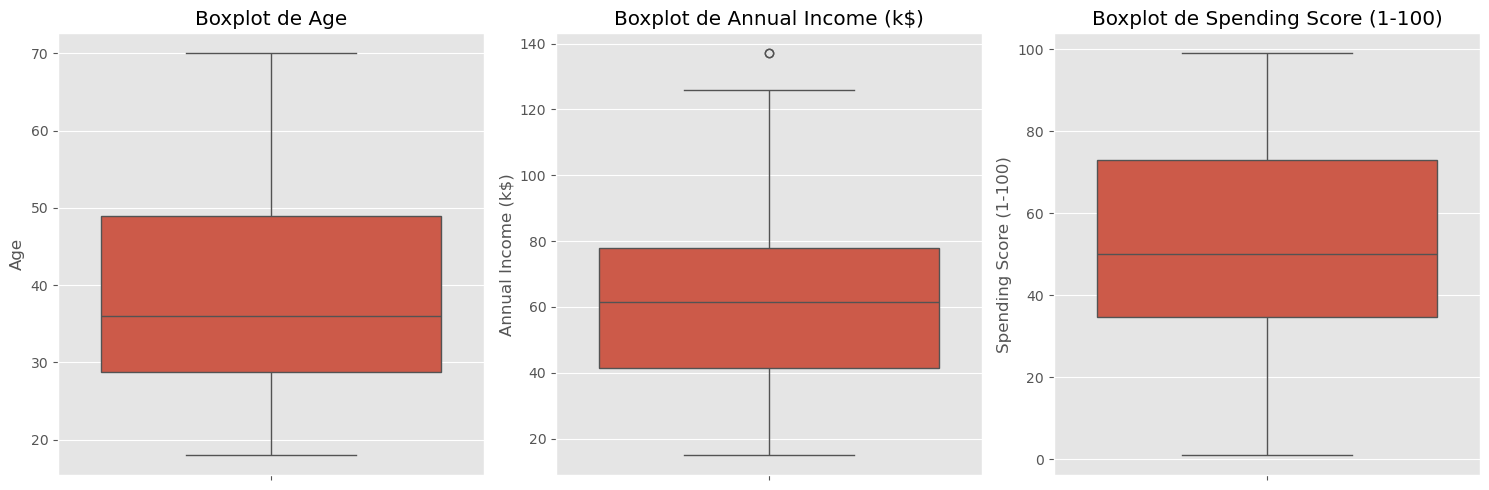

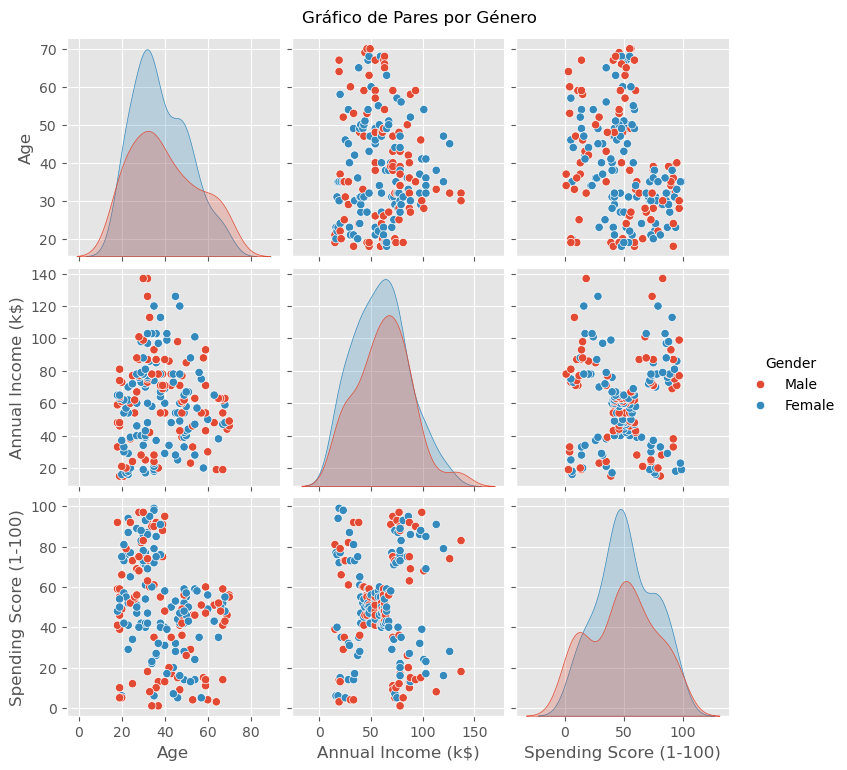

In [6]:
# 2. Visualización de los datos
# Histogramas
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# Gráfico de pares
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender')
plt.suptitle('Gráfico de Pares por Género', y=1.02)
plt.show()


In [7]:
# 3. Preparación para clustering
# Seleccionar características para clustering (excluyendo ID y Gender)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# 4. Matriz de distancia
# Calcular matriz de distancia euclidiana
distance_matrix = pdist(X_scaled, metric='euclidean')
distance_square = squareform(distance_matrix)

print("\nMatriz de distancia (primeras 5 filas/columnas):")
print(pd.DataFrame(distance_square).iloc[:5, :5])



Matriz de distancia (primeras 5 filas/columnas):
          0         1         2         3         4
0  0.000000  1.636811  1.283688  1.503375  0.865448
1  1.636811  0.000000  2.912751  0.214878  1.747665
2  1.283688  2.912751  0.000000  2.764727  1.538469
3  1.503375  0.214878  2.764727  0.000000  1.547361
4  0.865448  1.747665  1.538469  1.547361  0.000000


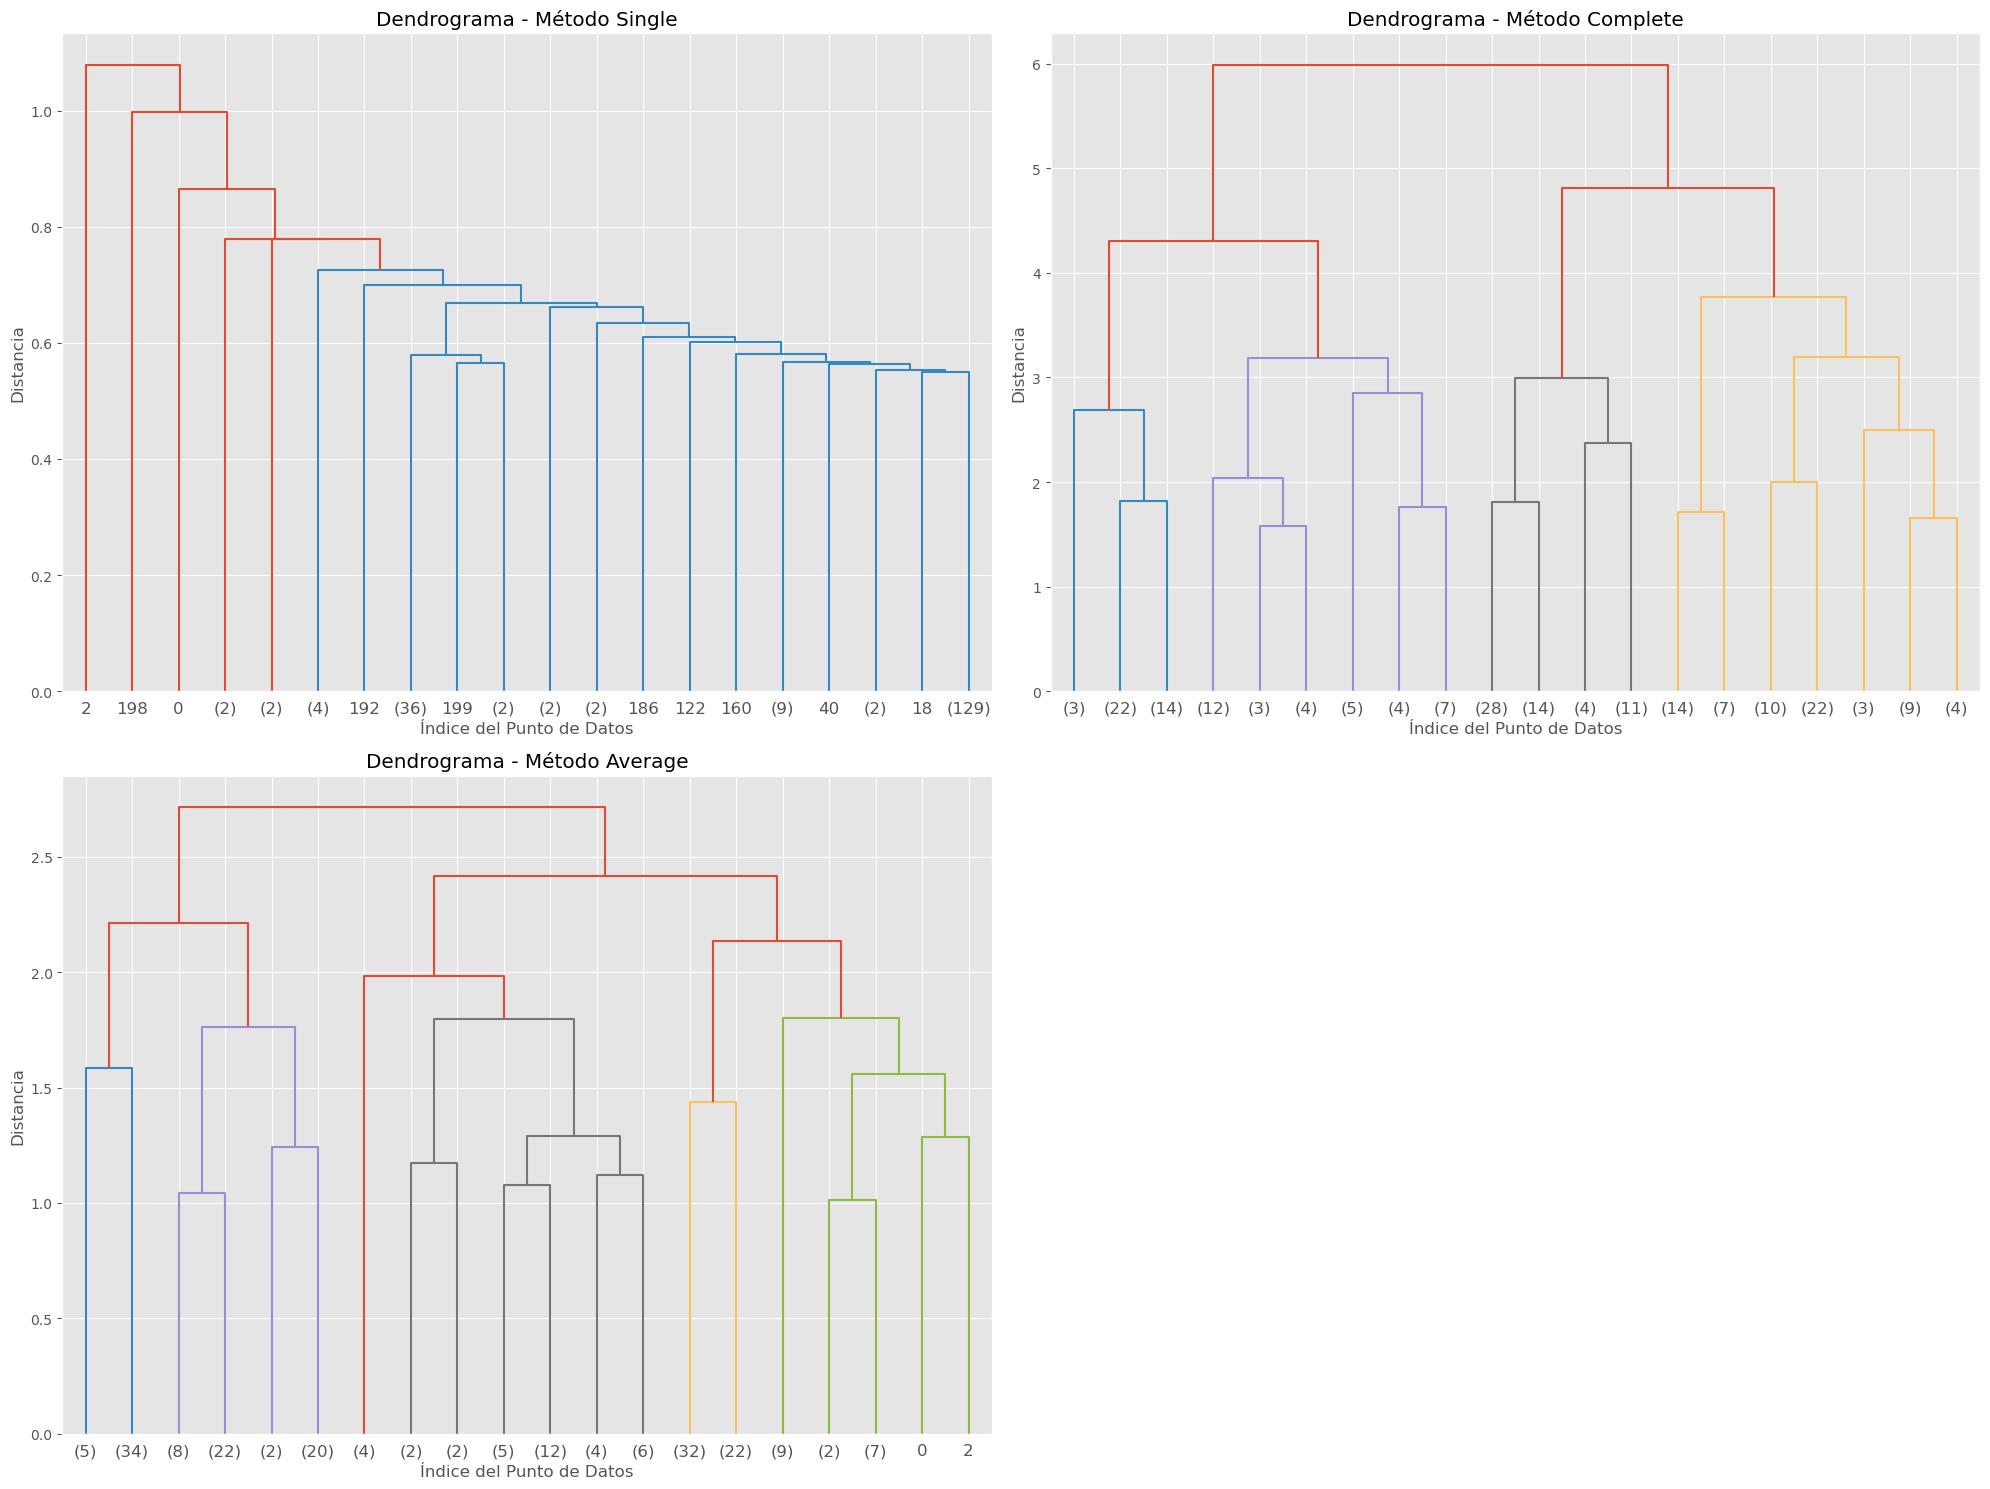

In [9]:
# 5. Dendrogramas
# Métodos de linkage para comparar
methods = ['single', 'complete', 'average']

plt.figure(figsize=(20, 15))
for i, method in enumerate(methods):
    plt.subplot(2, 2, i+1)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True)
    plt.title(f'Dendrograma - Método {method.capitalize()}')
    plt.xlabel('Índice del Punto de Datos')
    plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

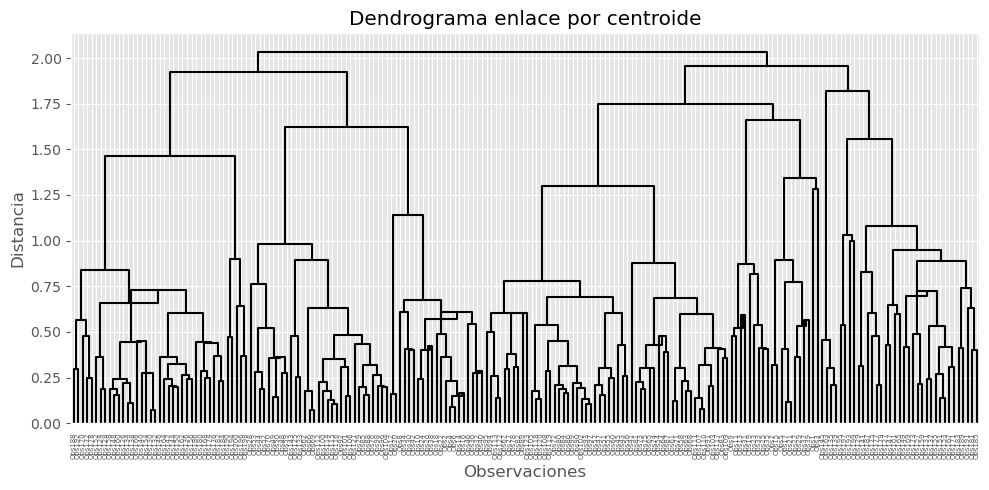

In [14]:
# Calcular distancias euclidianas
distancias = pdist(X_scaled, metric='euclidean')

# Enlace por centroide
hc = linkage(distancias, method='centroid')

# Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(hc, labels=[f'Obs{i+1}' for i in range(200)], 
    color_threshold=0,                # No aplicar color basado en corte
    above_threshold_color='black')     # Todo en negro
plt.title("Dendrograma enlace por centroide")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

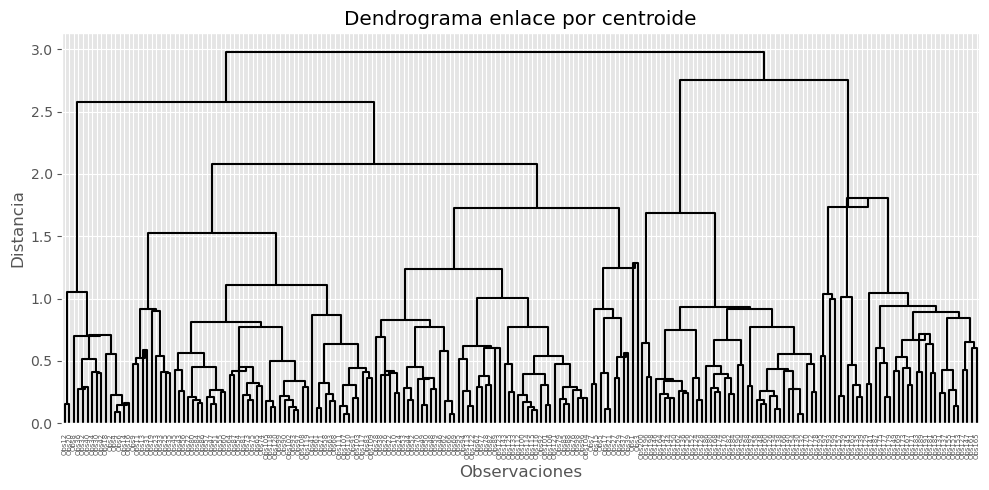

In [16]:
# Calcular distancias euclidianas
distancias = pdist(X_scaled, metric='euclidean')

# Enlace por centroide
hc = linkage(distancias, method='median')

# Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(hc, labels=[f'Obs{i+1}' for i in range(200)],
    color_threshold=0,                # No aplicar color basado en corte
    above_threshold_color='black')     # Todo en negro)
plt.title("Dendrograma enlace por centroide")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

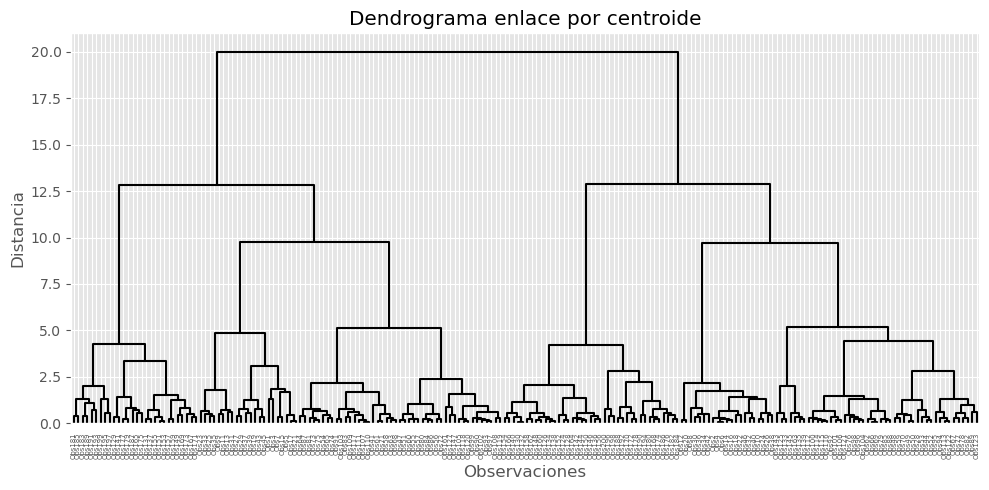

In [17]:
# Calcular distancias euclidianas
distancias = pdist(X_scaled, metric='euclidean')

# Enlace por centroide
hc = linkage(distancias, method='ward')

# Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(hc,
    labels=[f'Obs{i+1}' for i in range(200)],
    color_threshold=0,                # No aplicar color basado en corte
    above_threshold_color='black')     # Todo en negro)
plt.title("Dendrograma enlace por centroide")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


Evaluación del número óptimo de clusters:
Para n_clusters = 2, el coeficiente de silueta promedio es: 0.3249
Para n_clusters = 3, el coeficiente de silueta promedio es: 0.3400
Para n_clusters = 4, el coeficiente de silueta promedio es: 0.3839
Para n_clusters = 5, el coeficiente de silueta promedio es: 0.4096
Para n_clusters = 6, el coeficiente de silueta promedio es: 0.3896
Para n_clusters = 7, el coeficiente de silueta promedio es: 0.3800
Para n_clusters = 8, el coeficiente de silueta promedio es: 0.3756
Para n_clusters = 9, el coeficiente de silueta promedio es: 0.4069
Para n_clusters = 10, el coeficiente de silueta promedio es: 0.3954


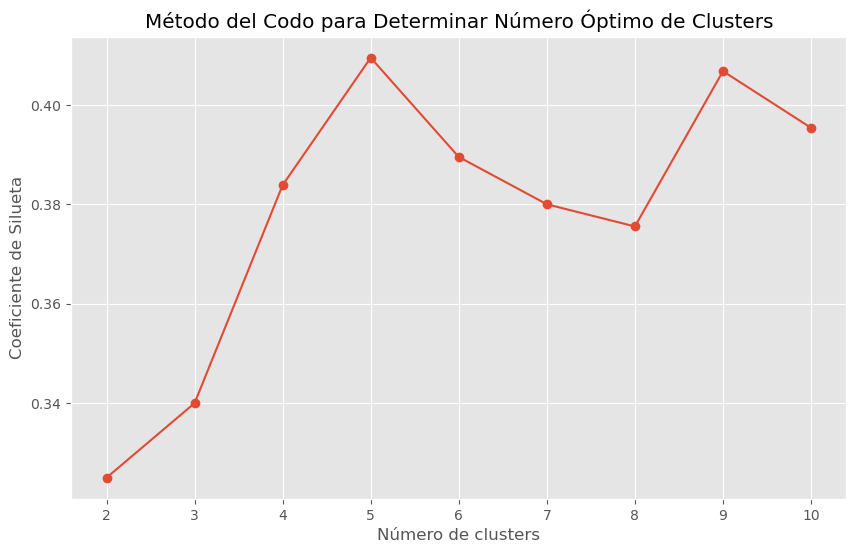

In [19]:
# 6. Determinación del número óptimo de clusters
# Usaremos el método del coeficiente de silueta y el criterio de inconsistencia

# Función para evaluar diferentes números de clusters
def find_optimal_clusters(X, max_clusters=10):
    silhouette_scores = []
    for n in range(2, max_clusters+1):
        # Remove affinity parameter as it is no longer supported
        clusterer = AgglomerativeClustering(n_clusters=n, linkage='average')  
        cluster_labels = clusterer.fit_predict(X)
        silhouette_avg = silhouette_score(X, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        print(f"Para n_clusters = {n}, el coeficiente de silueta promedio es: {silhouette_avg:.4f}")
    
    return silhouette_scores

# Evaluar con el método de linkage 'average' (el más comúnmente usado)
print("\nEvaluación del número óptimo de clusters:")
silhouette_scores = find_optimal_clusters(X_scaled)

# Visualizar los resultados del coeficiente de silueta
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Coeficiente de Silueta')
plt.title('Método del Codo para Determinar Número Óptimo de Clusters')
plt.grid(True)
plt.show()


In [9]:
# 7. Clusterización final
# Seleccionamos el número de clusters con el mayor coeficiente de silueta
optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 porque empezamos desde 2

# Aplicamos Agglomerative Clustering con los parámetros óptimos
final_clustering = AgglomerativeClustering(n_clusters=optimal_clusters, 
                                         linkage='average')  
cluster_labels = final_clustering.fit_predict(X_scaled)

# Añadimos las etiquetas al dataframe original
df['Cluster'] = cluster_labels


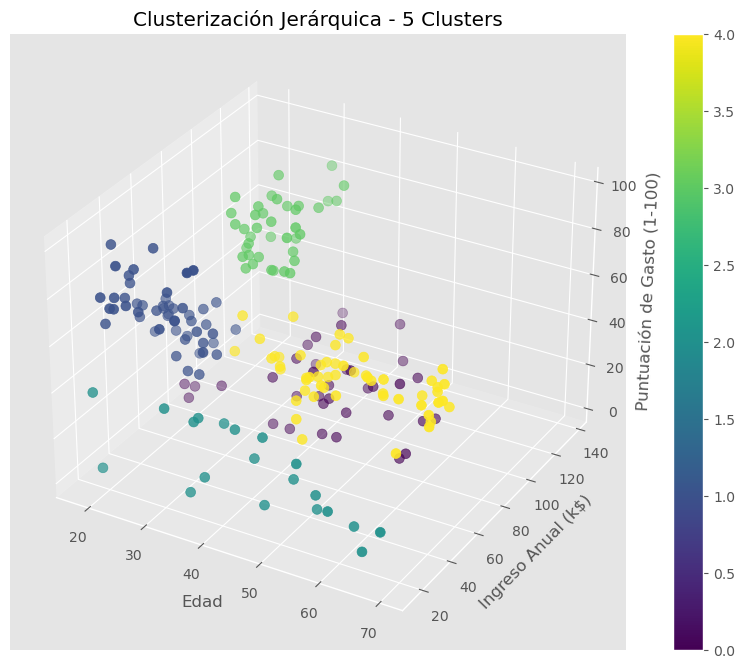

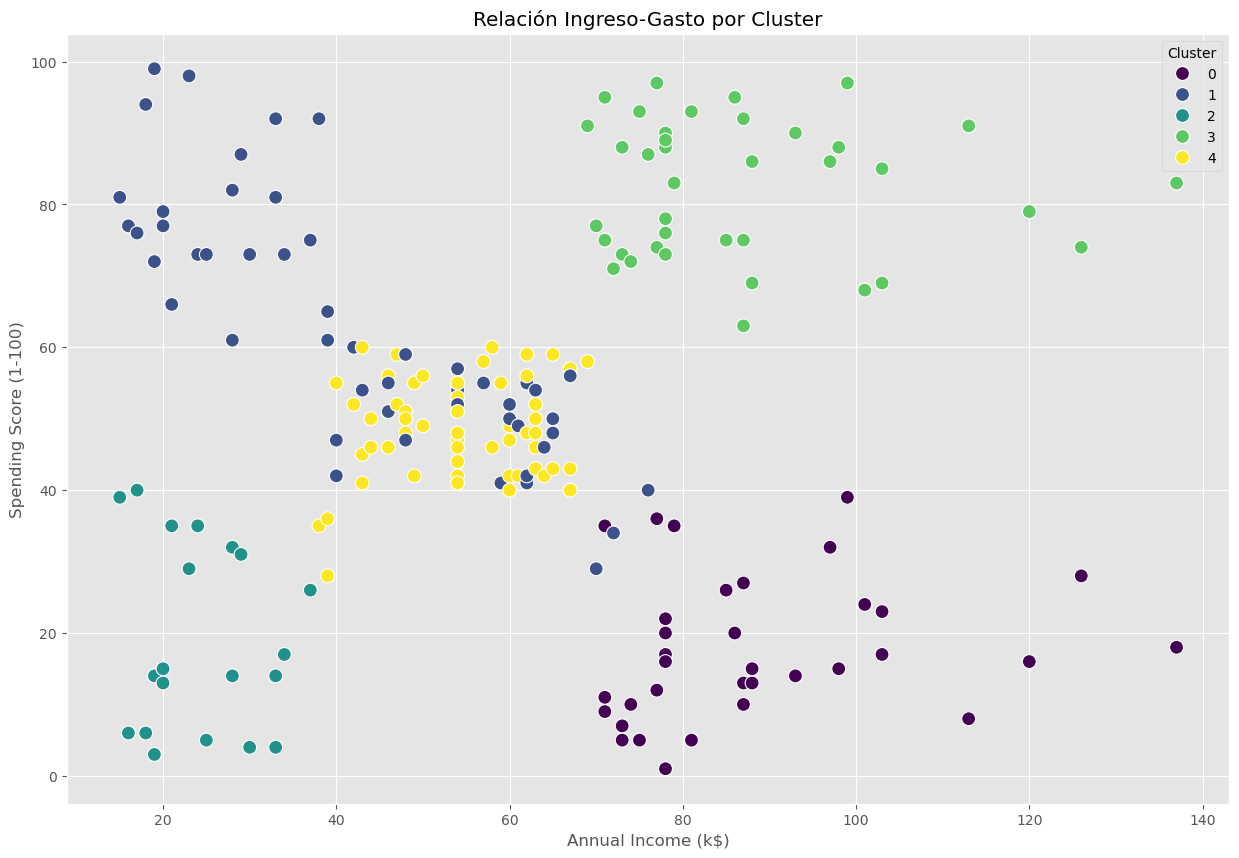

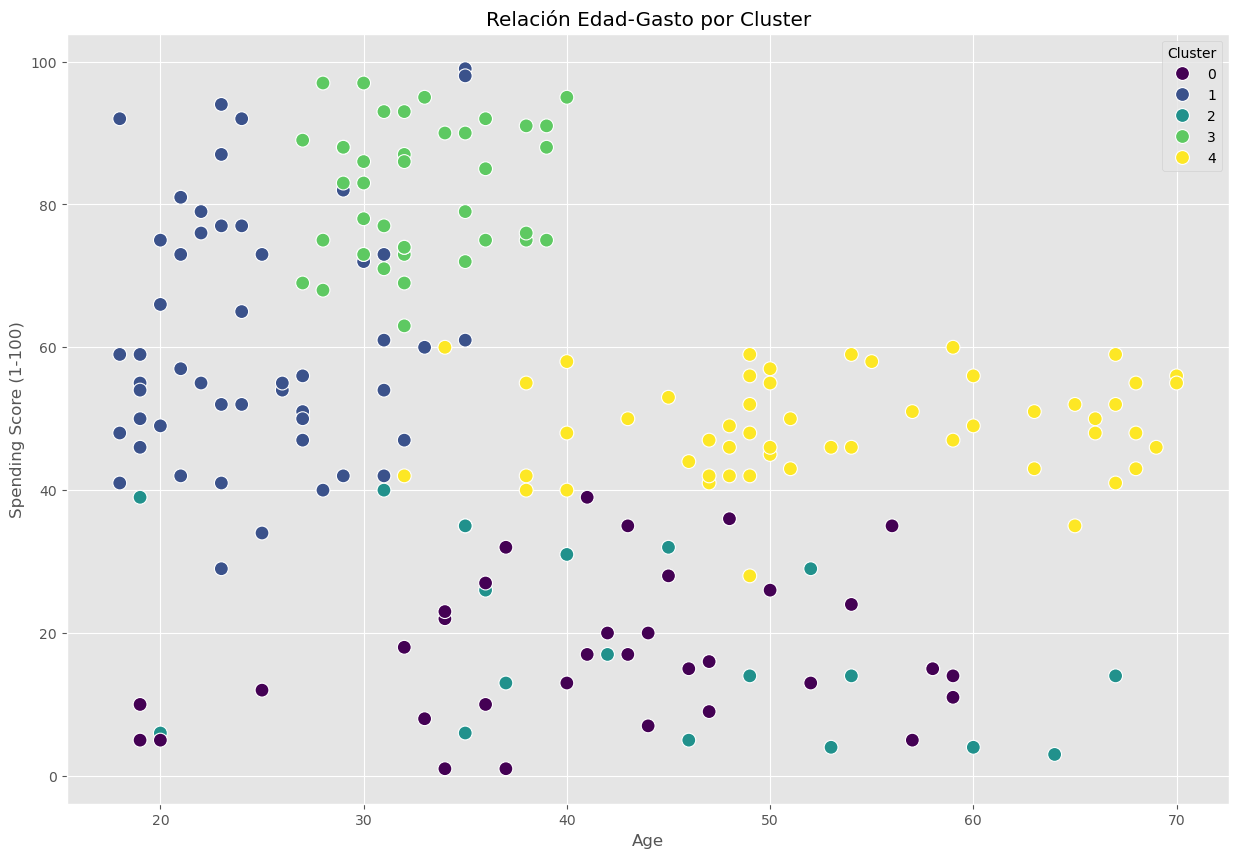

In [10]:
# 8. Visualización de los clusters
# Gráfico 3D de los clusters
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                    c=df['Cluster'], cmap='viridis', s=50)
ax.set_xlabel('Edad')
ax.set_ylabel('Ingreso Anual (k$)')
ax.set_zlabel('Puntuación de Gasto (1-100)')
plt.title(f'Clusterización Jerárquica - {optimal_clusters} Clusters')
plt.colorbar(scatter)
plt.show()

# Gráficos 2D por pares de variables
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=100)
plt.title('Relación Ingreso-Gasto por Cluster')
plt.show()

plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=100)
plt.title('Relación Edad-Gasto por Cluster')
plt.show()


In [11]:
# 9. Análisis de los clusters
# Estadísticas descriptivas por cluster
print("\nCaracterísticas de cada cluster:")
for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster}:")
    cluster_data = df[df['Cluster'] == cluster]
    print(cluster_data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe())
        # Distribución por género en cada cluster
    if 'Gender' in df.columns:
        print("\nDistribución por género:")
        print(cluster_data['Gender'].value_counts(normalize=True))


Características de cada cluster:

Cluster 0:
             Age  Annual Income (k$)  Spending Score (1-100)
count  35.000000           35.000000               35.000000
mean   41.685714           88.228571               17.285714
std    10.897305           16.367266               10.211215
min    19.000000           71.000000                1.000000
25%    35.000000           77.500000               10.000000
50%    43.000000           85.000000               16.000000
75%    47.500000           97.500000               23.500000
max    59.000000          137.000000               39.000000

Distribución por género:
Gender
Male      0.571429
Female    0.428571
Name: proportion, dtype: float64

Cluster 1:
             Age  Annual Income (k$)  Spending Score (1-100)
count  52.000000           52.000000               52.000000
mean   24.653846           42.942308               62.076923
std     4.942352           17.571605               17.428674
min    18.000000           15.000000         